<a href="https://colab.research.google.com/github/AI-is-out-there/SkillFactory-DataScience-MED/blob/main/code/part-4-EEG_wavelets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook Code Overview

**Учебный ноутбу**к - обработка простых математических и медицинских данных ЭЭГ и ЭКГ


Примеры научных статей о применении wavelet в биоинформатике:
Грубов В. В., Овчинников А. А., Ситникова Е. Ю., Короновский А. А., Храмов А. Е. Вейвлетный анализ сонных веретен на ЭЭГ и разработка метода их автоматической диагностики // Известия вузов. ПНД. 2011. Т. 19, вып. 4. С. 91-108. DOI: 10.18500/0869-6632-2011-19-4-91-108
[ссылка на статью](https://andjournal.sgu.ru/ru/articles/veyvletnyy-analiz-sonnyh-vereten-na-eeg-i-razrabotka-metoda-ih-avtomaticheskoy-diagnostiki)

[Ссылка](https://ataspinar.com/2018/12/21/a-guide-for-using-the-wavelet-transform-in-machine-learning/) на примеры кода как использовать Wavelet:

Полезные ссылки на литературу:

https://habr.com/ru/articles/460445/

https://www.scicoding.com/introduction-to-wavelet-transform-using-python/



In [1]:
# устанавливаем библиотеку для загрузки зависимостей
# для обработки данных с помощью вейвлетов
!pip install pywavelets mne --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 26.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [2]:
# подгружаем библиотеки
import pywt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne

In [3]:
# фильтр Баттерфорда для вырезания полосы частот
from scipy import signal
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    filtered_data = signal.lfilter(b, a, data)
    return filtered_data

In [4]:
# функция преобразования Гильберта для построения огибающей
from scipy.fft import fft, ifft
def my_func_hilbert(x):
    N = len(x)
    xf = fft(x)
    xf[1:N//2] *= 2
    if N % 2 == 1:
        xf[N//2] *= 2
    xf[N//2 + 1:] = 0
    xa = ifft(xf)
    assert np.allclose(xa.real, x)
    return xa

In [5]:
# модули для обработки временных рядов (убрать тренд и аппроксимировать)
class Detrending:
  def plot(t,y,slope,intercept):
    fig = plt.figure(figsize=(10,7))
    ax = plt.subplot(111)
    plt.scatter(t,y, s=5)
    plt.plot(t, slope*t + intercept, 'r',
             label='y={:.2f}x+{:.2f}'.format(slope,intercept))
    plt.grid(True)
    plt.legend(fontsize=12)
    plt.xlabel('time')
    plt.ylabel('Y')
    plt.show()

  def line_fit(t,y):
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(t,y)
    #line = slope*t + intercept
    return slope, intercept

  def trend_off(t,y):
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(t,y)
    line = slope*t + intercept

    y_nontrend = y-line
    return y_nontrend


## Пример загрузки ЭЭГ формата EDF из базы данных Zenodo

In [6]:
!pip install zenodo_get --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.7 MB/s eta 0:00:00


In [7]:
import zenodo_get

In [12]:
# ссылка на базу данных ЭЭГ
#https://zenodo.org/records/2547147#.Y7eU5uxBwlI

#это команда для загрузки EDF из базы - файл попадаем сразу в ноутбук

!zenodo_get "10.5281/zenodo.4940267" -k -g eeg17.edf
data_from_raw_edf = mne.io.read_raw_edf('/content/eeg17.edf', preload=True)

INFO: Output directory: /content
INFO: Title: A dataset of neonatal EEG recordings with seizures annotations
INFO: Total size: 59.1 MB
INFO: Number of files: 1
SUCCESS: All specified files have been processed.
Extracting EDF parameters from /content/eeg17.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1406207  =      0.000 ...  5492.996 secs...


/tmp/ipykernel_2999/3949335.py:7: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  data_from_raw_edf = mne.io.read_raw_edf('/content/eeg17.edf', preload=True)
/tmp/ipykernel_2999/3949335.py:7: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  data_from_raw_edf = mne.io.read_raw_edf('/content/eeg17.edf', preload=True)


Using matplotlib as 2D backend.
['EEG Fp1-Ref', 'EEG Fp2-Ref', 'EEG F3-Ref', 'EEG F4-Ref', 'EEG F7-Ref', 'EEG F8-Ref', 'EEG Fz-Ref', 'EEG C3-Ref', 'EEG C4-Ref', 'EEG Cz-Ref', 'EEG T3-Ref', 'EEG T5-Ref', 'EEG T4-Ref', 'EEG T6-Ref', 'EEG P3-Ref', 'EEG P4-Ref', 'EEG Pz-Ref', 'EEG O1-Ref', 'EEG O2-Ref', 'ECG EKG', 'Resp Effort']


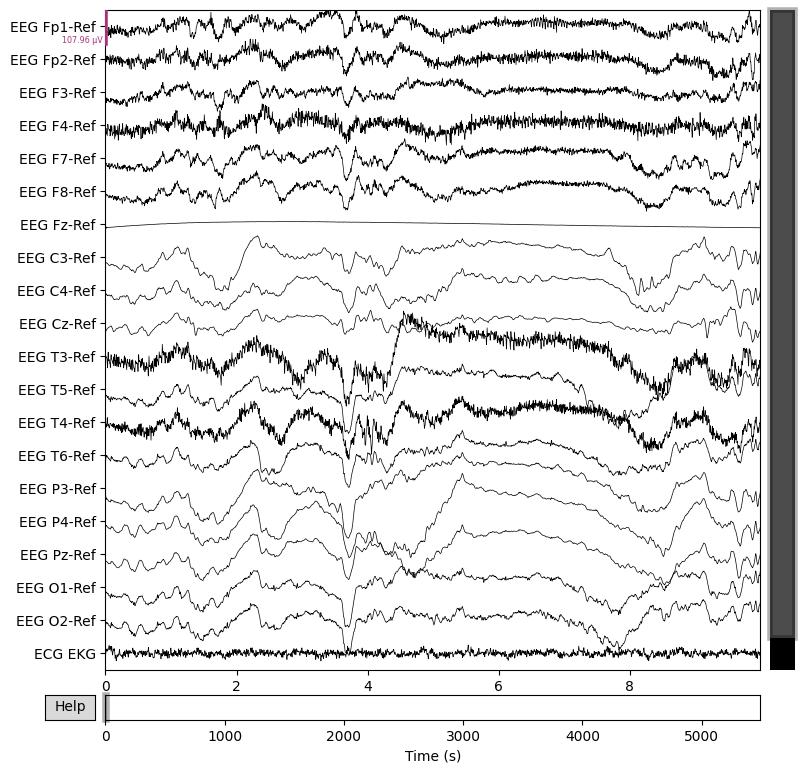

In [13]:
# EDF - файл содержит многоканальную запись ЭЭГ
# ECG - файл содержит запись электрокардиограммы
data_from_raw_edf.plot(scalings = 'auto', show = False)
# список каналов из файла EDF
print(data_from_raw_edf.ch_names)

# Определяем время приступа по данным из датасета zenodo

In [36]:

# Download annotations file
!wget -O /content/annotations_2017_A_fixed.csv \
    "https://zenodo.org/records/4940267/files/annotations_2017_A_fixed.csv"

# =============================================================================
# STEP 1: Load EEG data and annotations
# =============================================================================
# Load EDF file
raw = mne.io.read_raw_edf('/content/eeg17.edf', preload=True, verbose=False)
sfreq = raw.info['sfreq']  # Sampling frequency (Hz)
eeg_data, eeg_times = raw.get_data(return_times=True)

# Load annotations CSV
annotations_df = pd.read_csv('/content/annotations_2017_A_fixed.csv')

# Extract seizure annotations for patient 17 (column name is "17")
# Skip header row handling: pandas reads first row as column names
seizure_annotations = annotations_df['17'].values.astype(int)

print(f"EEG duration: {eeg_times[-1]:.2f} seconds")
print(f"Annotation length: {len(seizure_annotations)} samples")
print(f"Sampling frequency: {sfreq} Hz")

# =============================================================================
# STEP 2: Find seizure segments and map to time indices
# =============================================================================
def find_seizure_segments(annotations, min_duration_samples=0):
    """
    Find start/end indices of seizure segments in binary annotation array.

    Parameters:
    -----------
    annotations : array-like
        Binary array (0=non-seizure, 1=seizure)
    min_duration_samples : int
        Minimum seizure duration in samples (default: 0 = no filtering)

    Returns:
    --------
    list of tuples: [(start_idx, end_idx, duration_sec), ...]
    """
    segments = []
    in_seizure = False
    start_idx = None

    for i, val in enumerate(annotations):
        if val == 1 and not in_seizure:
            # Seizure start
            in_seizure = True
            start_idx = i
        elif val == 0 and in_seizure:
            # Seizure end
            in_seizure = False
            end_idx = i
            duration = end_idx - start_idx
            if duration >= min_duration_samples:
                duration_sec = duration / sfreq
                segments.append((start_idx, end_idx, duration_sec))

    # Handle case where recording ends during seizure
    if in_seizure:
        end_idx = len(annotations)
        duration = end_idx - start_idx
        if duration >= min_duration_samples:
            duration_sec = duration / sfreq
            segments.append((start_idx, end_idx, duration_sec))

    return segments

# Find all seizure segments for patient 17
seizure_segments = find_seizure_segments(seizure_annotations)

print(f"\nFound {len(seizure_segments)} seizure segment(s) for patient 17:")
for i, (start_idx, end_idx, dur_sec) in enumerate(seizure_segments, 1):
    start_time = eeg_times[start_idx] if start_idx < len(eeg_times) else eeg_times[-1]
    end_time = eeg_times[end_idx-1] if end_idx <= len(eeg_times) else eeg_times[-1]
    print(f"  Seizure {i}: indices [{start_idx}:{end_idx}], "
          f"time [{start_time:.2f}s : {end_time:.2f}s], "
          f"duration {dur_sec:.2f}s")

# =============================================================================
# STEP 3: Get t_index_begin and t_index_end for a specific seizure (your use case)
# =============================================================================
# Example: Get indices for the FIRST seizure with buffer (like your original code)
if len(seizure_segments) > 0:
    # Select first seizure
    seizure_idx = 0  # Change this to select different seizure
    t_index_begin_raw, t_index_end_raw, _ = seizure_segments[seizure_idx]

    # Add buffer around seizure (e.g., 480 samples = ~2 seconds at 256 Hz)
    buffer_samples = 480
    t_index_begin = max(0, t_index_begin_raw - buffer_samples)
    t_index_end = min(len(eeg_times), t_index_end_raw + buffer_samples)

    print(f"\n=== Selected seizure {seizure_idx + 1} ===")
    print(f"t_index_begin: {t_index_begin} (time: {eeg_times[t_index_begin]:.2f}s)")
    print(f"t_index_end: {t_index_end} (time: {eeg_times[t_index_end-1]:.2f}s)")

    # Extract time vector and data for this segment
    t = eeg_times[t_index_begin:t_index_end]
    T = t[-1] - t[0]  # Duration
    N = len(t)        # Number of samples

    print(f"Segment duration: {T:.2f}s, samples: {N}")

    # Remove last channel if needed (as in your original code)
    # Note: verify channel count matches your expectations
    if eeg_data.shape[0] > 1:
        eeg_segment = eeg_data[:, t_index_begin:t_index_end]
        # Your original code removed last channel - adjust if needed:
        # eeg_segment = np.delete(eeg_segment, [-1], axis=0)
else:
    print("\nNo seizures annotated for patient 17 in this recording.")

--2026-04-15 11:47:48--  https://zenodo.org/records/4940267/files/annotations_2017_A_fixed.csv
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.43.153, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1636334 (1.6M) [text/plain]
Saving to: ‘/content/annotations_2017_A_fixed.csv’

/content/annotation 100%[===================>]   1.56M  --.-KB/s    in 0.1s    

2026-04-15 11:47:48 (14.4 MB/s) - ‘/content/annotations_2017_A_fixed.csv’ saved [1636334/1636334]



/tmp/ipykernel_2999/2667391036.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf('/content/eeg17.edf', preload=True, verbose=False)
/tmp/ipykernel_2999/2667391036.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf('/content/eeg17.edf', preload=True, verbose=False)


EEG duration: 5493.00 seconds
Annotation length: 15416 samples
Sampling frequency: 256.0 Hz

Found 4 seizure segment(s) for patient 17:
  Seizure 1: indices [2956:3011], time [11.55s : 11.76s], duration 0.21s
  Seizure 2: indices [3060:3112], time [11.95s : 12.15s], duration 0.20s
  Seizure 3: indices [5281:5323], time [20.63s : 20.79s], duration 0.16s
  Seizure 4: indices [5379:5401], time [21.01s : 21.09s], duration 0.09s

=== Selected seizure 1 ===
t_index_begin: 2476 (time: 9.67s)
t_index_end: 3491 (time: 13.63s)
Segment duration: 3.96s, samples: 1015


/tmp/ipykernel_2999/2667391036.py:17: RuntimeWarning: invalid value encountered in cast
  seizure_annotations = annotations_df['17'].values.astype(int)


In [37]:
#время приступ узнаем из аннотации из базы данных
eeg_data, eeg_times = data_from_raw_edf.get_data(return_times=True)
print('число отчетов во временном ряду:',len(eeg_times))

# устанавливаем диапазон для обработки данных
t_index_begin = np.where(eeg_times > 1*2476 -480)[0][0]
t_index_end = np.where(eeg_times > 1*3491 + 480)[0][0]
t = eeg_times[t_index_begin:t_index_end]
# значение времени = конец сигнала
T = t[-1] - t[0]
# число элементов во временном ряду
N = len(t)

# удалаем ненужные сигналы из массива данных ЭЭГ
# в случае сигнала EEG_21 8 канал 'Value MKR+-MKR-'
eeg_data = np.delete(eeg_data, [len(eeg_data)-1], axis = 0)

число отчетов во временном ряду: 1406208


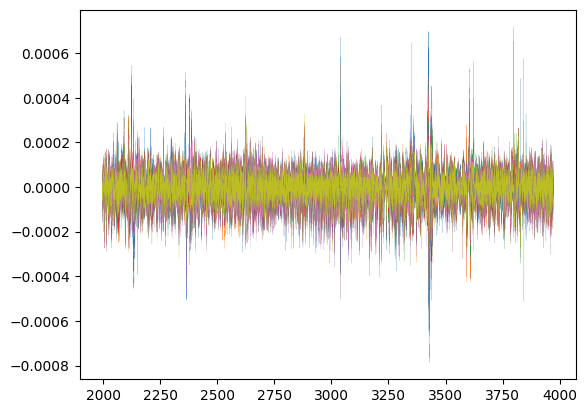

In [38]:
for i in range(len(data_from_raw_edf.ch_names)-2):
    plt.plot(t, eeg_data[i, t_index_begin:t_index_end],linewidth = 0.1)
plt.show()

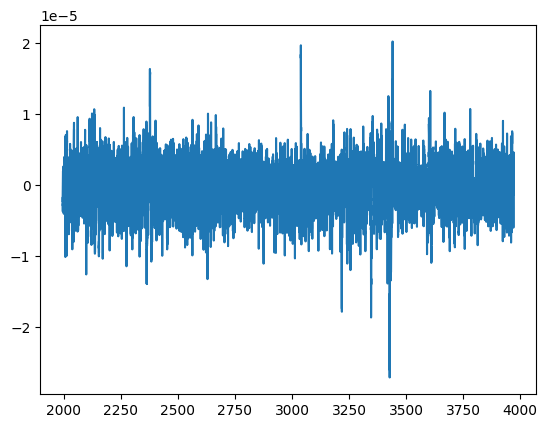

In [39]:
# сделаем простой устредненный сигнал - все каналы в один массив
y=[]
for i in range(len(eeg_data)-2):
    y =+ eeg_data[i, t_index_begin:t_index_end]
y =y/(len(eeg_data)-1)
plt.plot(t,y)

# Пример фильтрации сигналов

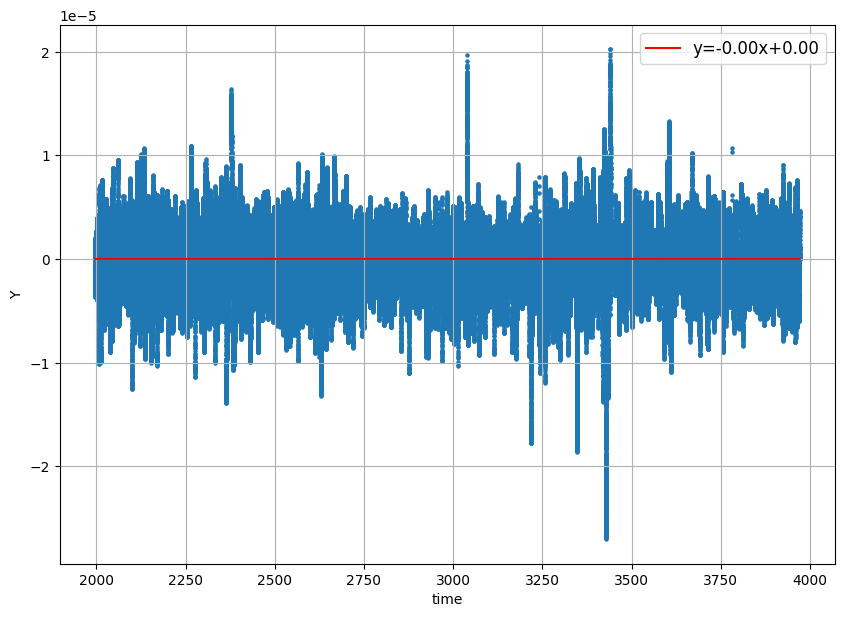

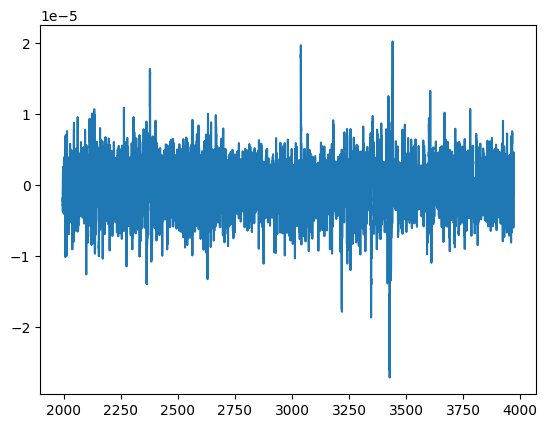

In [40]:
slope, intercept = Detrending.line_fit(t, y)
Detrending.plot(t,y,slope, intercept)

y = Detrending.trend_off(t,y)
plt.plot(t,y)

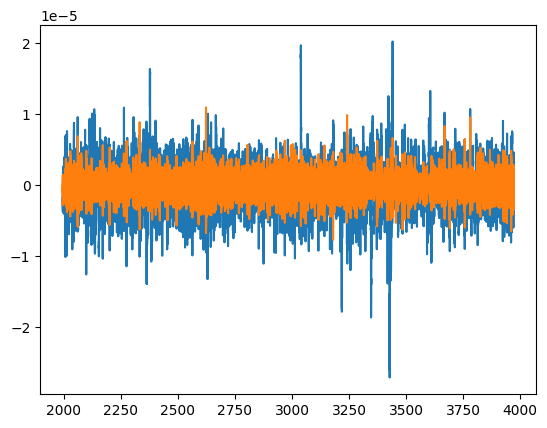

In [41]:
# Пример предобработки: фильтрация сигнала
fs = len(t)/(T)  # частота дискретизации
lowcut = 1 # нижняя частота среза фильтра
highcut = 60 # верхняя частота среза фильтра
y_filt = np.apply_along_axis(butter_bandpass_filter, axis=0, arr=y, lowcut=lowcut, highcut=highcut, fs=fs)
plt.plot(t,y, t, y_filt)
y = y_filt

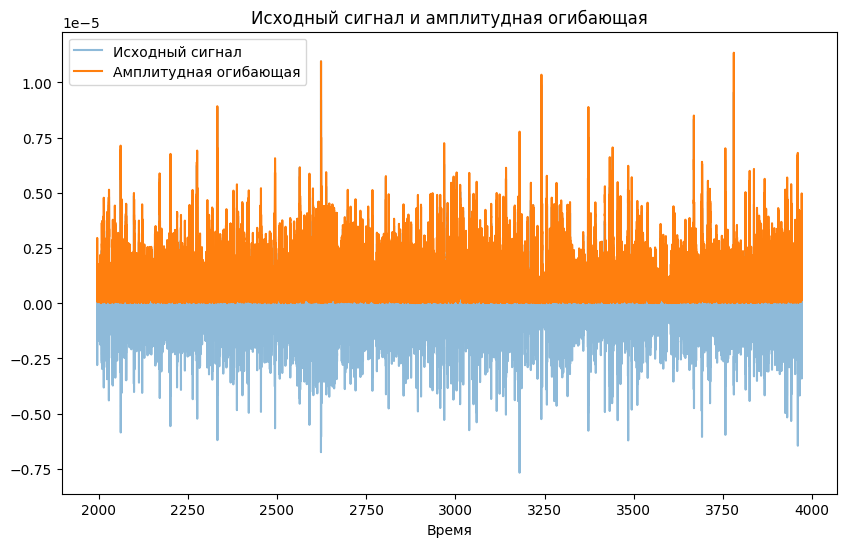

In [42]:
# Применяем преобразование Гильберта
analytic_signal = my_func_hilbert(y)
amplitude_envelope = np.abs(analytic_signal)  # Используем амплитуду для амплитудной огибающей

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(t, y, label='Исходный сигнал', alpha=0.5)
plt.plot(t, amplitude_envelope, label='Амплитудная огибающая')


plt.title('Исходный сигнал и амплитудная огибающая')
plt.xlabel('Время')
plt.legend()

plt.show()

In [43]:
# Определение частотных диапазонов
delta_band = (0.5, 4)
theta_band = (4, 8)
alpha_band = (8, 13)
beta_band = (13, 30)
gamma_band = (30, 75)

band_names = ('delta','theta','alpha','beta','gamma')
band_value = (0.5, 4, 8, 13, 30, 50)
fs = int(len(t)/(T))  # частота дискретизации

<Figure size 640x480 with 0 Axes>

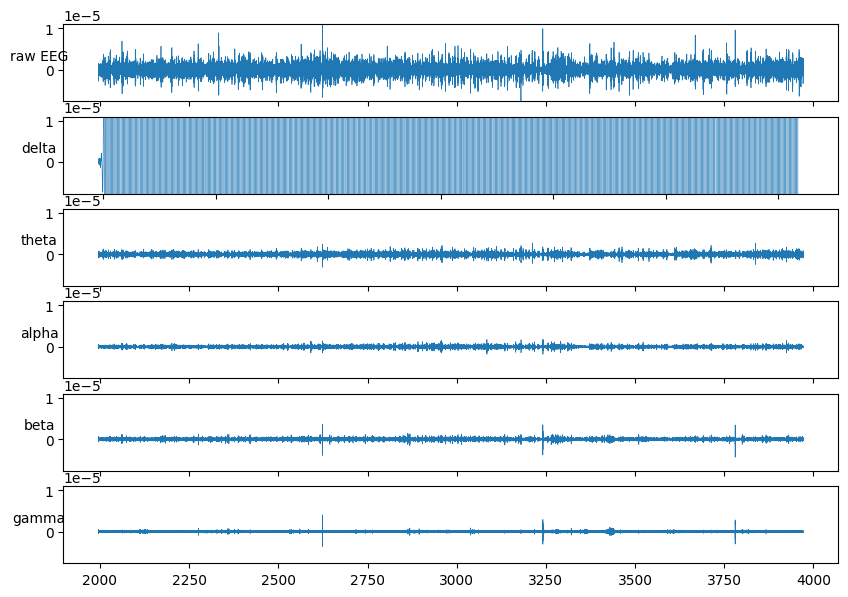

In [44]:
fig = plt.figure()
fig, ax = plt.subplots(6,1,figsize=(10,7))
ax[0].set_ylim(np.min(y), np.max(y))
ax[0].plot(t, y,linewidth = 0.5)
ax[0].set_ylabel('raw EEG', rotation = 0)

for i in range(1,6):
    ax[i].set_ylim(np.min(y), np.max(y))
    #ax[i-1].set_yticklabels(np.arange(-25, 25, step=25))
    #ax[i-1].set_yticklabels([])
    ax[i-1].set_xticklabels([])
    ax[i].set_ylabel(band_names[i-1], rotation = 0)
    filtered_signals = np.apply_along_axis(butter_bandpass_filter, axis=0, arr=y, lowcut=band_value[i-1], highcut=band_value[i], fs=fs)
    ax[i].plot(t, filtered_signals,linewidth = 0.5)

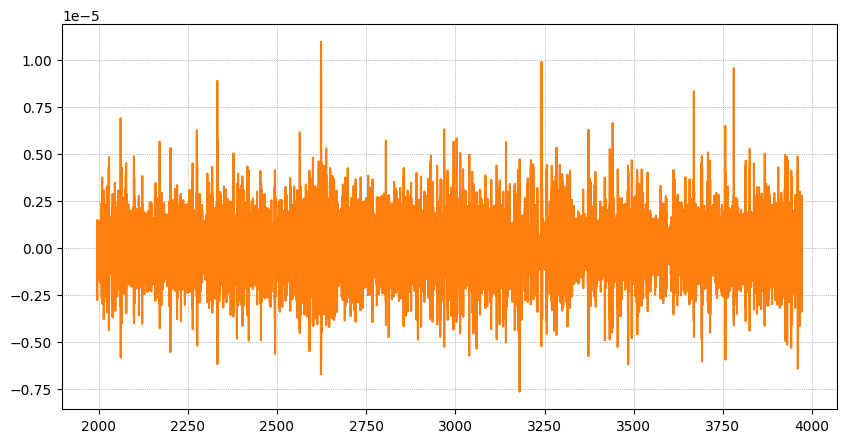

In [45]:
# График отфильтрованного сигнала во времени
plt.figure(figsize=(10, 5))
plt.plot(t,filtered_signals)
plt.plot(t,y)
plt.grid(color='gray', linestyle=':', linewidth=0.5)
plt.show()

# Пример - визуализация медицинских временных рядов

## Визуализация сигнала: спектр Фурье

число точек в диапазоне преобразования Фурье: 252800
максимальная частота 127.99974683494231


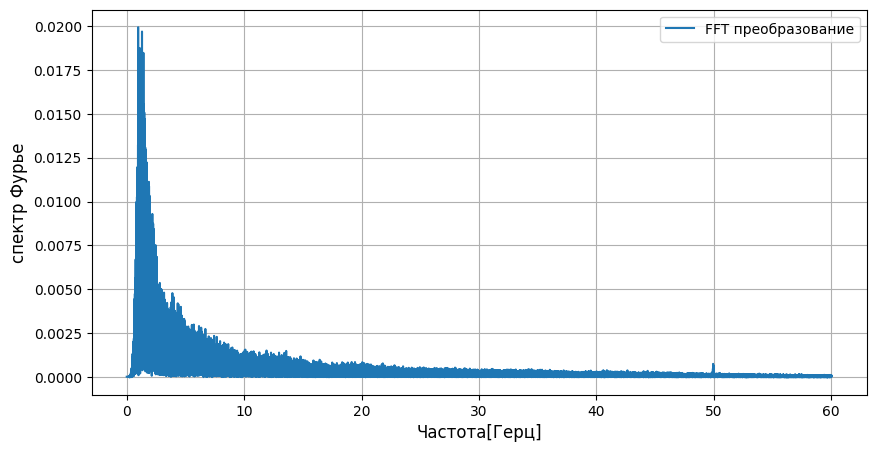

In [46]:
from scipy.fft import fft, fftfreq

y = y_filt
yfft = fft(y)
xf = fftfreq(N, T/N)[:N//2]
yf = np.abs(yfft[0:N//2])

# устанавливаем максимальную частоту для отображения на графике преобразования Фурье
f_viewmax = 60
if len(np.where(xf > f_viewmax)[0]) == 0:
  index_f_viewmax = len(xf)
else:
  index_f_viewmax = np.where(xf > f_viewmax)[0][0]
print('число точек в диапазоне преобразования Фурье:',len(xf))
print('максимальная частота', xf[-1])
# спект Фурье симметричен относительно нуля, поэтому берем только правую его часть
plt.figure(figsize=(10, 5))
plt.plot(xf[0:index_f_viewmax], yf[0:index_f_viewmax], label='FFT преобразование')
plt.xlabel('Частота[Герц]', fontsize=12)
plt.ylabel('спектр Фурье', fontsize=12)
#plt.xticks(np.arange(1, np.max(xf[0:100]), 2))
plt.grid()
plt.legend()
plt.show()

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_2999/112353675.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data_from_raw_edf.plot_psd(fmin=1, fmax=f_viewmax, tmax=np.inf, show=False)


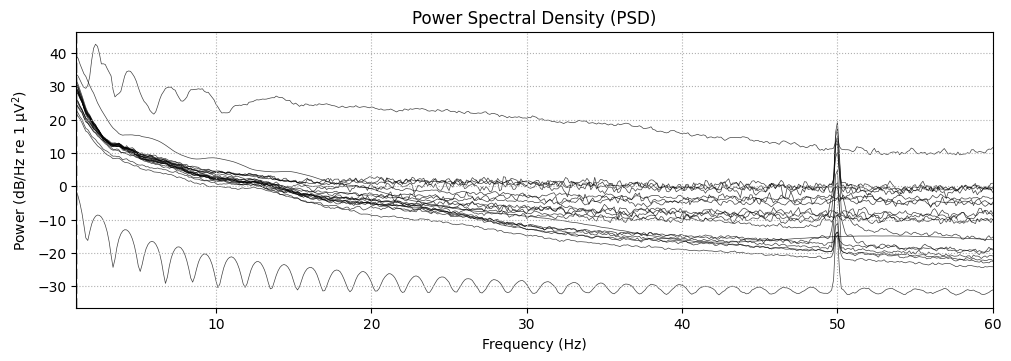

In [47]:
# Построение спектра плотности мощности
data_from_raw_edf.plot_psd(fmin=1, fmax=f_viewmax, tmax=np.inf, show=False)
plt.title('Power Spectral Density (PSD)')
plt.show()

/tmp/ipykernel_2999/3448492961.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(psd[indices], freqs[indices])


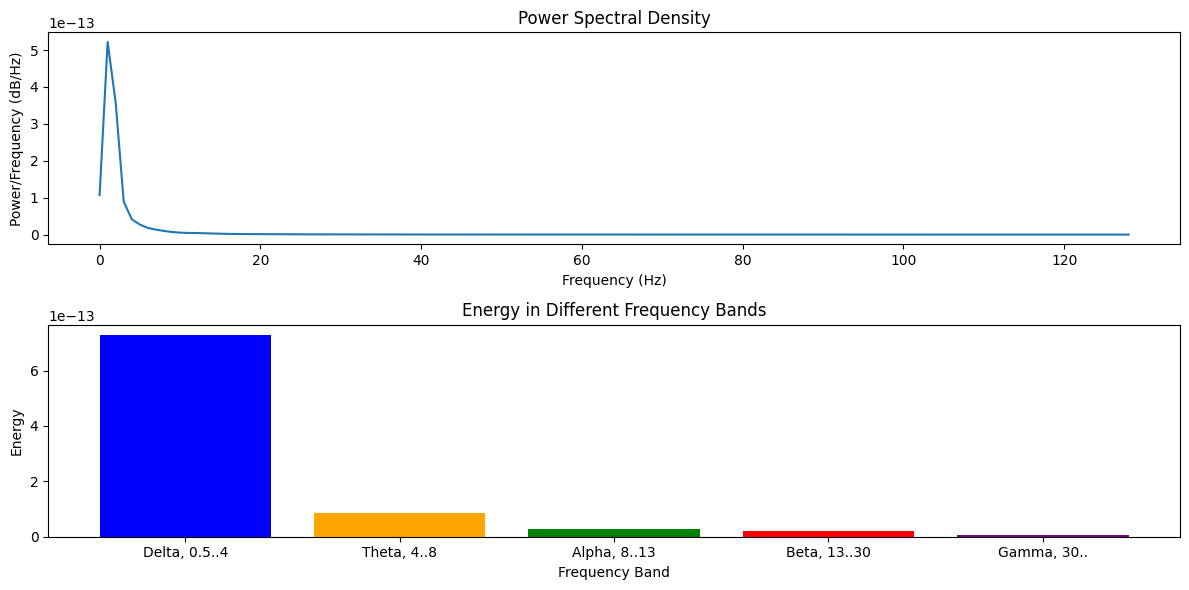

In [48]:
from scipy.signal import welch

# Функция для вычисления энергии в заданном частотном диапазоне
def compute_energy_in_frequency_band(freqs, psd, band):
    indices = np.where((freqs >= band[0]) & (freqs <= band[1]))[0]
    energy = np.trapz(psd[indices], freqs[indices])
    return energy

# Функция для построения спектрограммы и вычисления энергии в различных частотных диапазонах
def plot_spectrogram_and_energy(signal, sample_rate):
    # Вычисление мощности спектра с помощью метода Велча
    freqs, psd = welch(signal, sample_rate)#, nperseg=1024)

    # Определение частотных диапазонов
    delta_band = (0.5, 4)
    theta_band = (4, 8)
    alpha_band = (8, 13)
    beta_band = (13, 30)
    gamma_band = (30, 100)

    # Вычисление энергии в каждом частотном диапазоне
    energy_delta = compute_energy_in_frequency_band(freqs, psd, delta_band)
    energy_theta = compute_energy_in_frequency_band(freqs, psd, theta_band)
    energy_alpha = compute_energy_in_frequency_band(freqs, psd, alpha_band)
    energy_beta  = compute_energy_in_frequency_band(freqs, psd, beta_band)
    energy_gamma = compute_energy_in_frequency_band(freqs, psd, gamma_band)

    # Построение спектрограммы
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(freqs, psd)
    plt.title('Power Spectral Density')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power/Frequency (dB/Hz)')

    # Построение энергии в различных частотных диапазонах
    plt.subplot(2, 1, 2)
    bands = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
    energies = [energy_delta, energy_theta, energy_alpha, energy_beta, energy_gamma]
    plt.bar(bands, energies, color=['blue', 'orange', 'green', 'red', 'purple'])
    plt.title('Energy in Different Frequency Bands')
    plt.xlabel('Frequency Band')
    plt.xticks(np.arange(5), ('Delta, 0.5..4', 'Theta, 4..8', 'Alpha, 8..13', 'Beta, 13..30', 'Gamma, 30..'))
    plt.ylabel('Energy')

    plt.tight_layout()
    plt.show()

#sample_rate частота дискретизации
sample_rate = fs
plot_spectrogram_and_energy(y, sample_rate)


# Вейвлет преобразования CWT

In [49]:
# перечень вейвлетов
wavlist_continuous = pywt.wavelist(kind='continuous')
wavlist_discrete = pywt.wavelist(kind='discrete')

In [50]:
# устанавливаем максимальное значение сдвига
# не путать с частотой

#For the cmor, fbsp and shan wavelets, the user can specify a specific a normalized center frequency.
#A value of 1.0 corresponds to 1/dt where dt is the sampling period.
#In other words, when analyzing a signal sampled at 100 Hz,
#a center frequency of 1.0 corresponds to ~100 Hz at scale = 1.
#This is above the Nyquist rate of 50 Hz, so for this particular wavelet, one would analyze a signal using scales >= 2.

scale_max = 300
scale_min = 3
# массив точек с масштабом (линейный и логарифмический масштаб)
scales = np.linspace(scale_min, scale_max, num = 25, endpoint=True)
#scales = np.logspace(np.log10(scale_min), np.log10(scale_max), num = 25, endpoint=True, base=10.0)

wavelet_core = 'morl'
#dt = t[1] - t[0]
fs = len(t)/(T)  # частота дискретизации
dt = 1/ fs
coef, freqs = pywt.cwt(y, scales, wavelet_core, sampling_period = dt)

# freqs = These are normalized frequencies, which means that you need
# to multiply them by your sampling frequency = fs
# to turn them into actual frequencies.

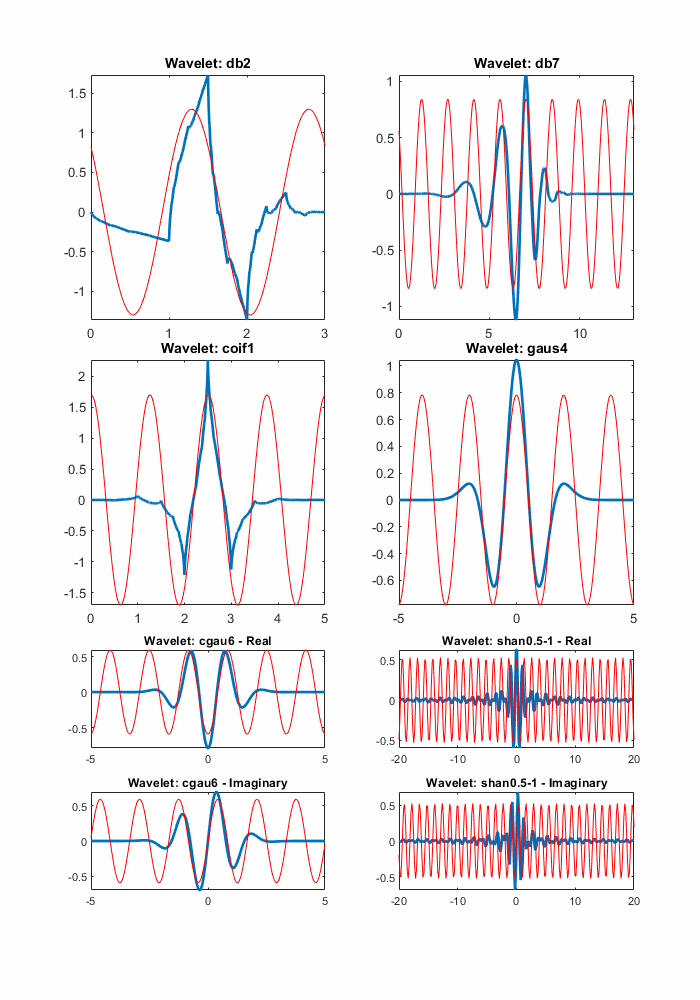

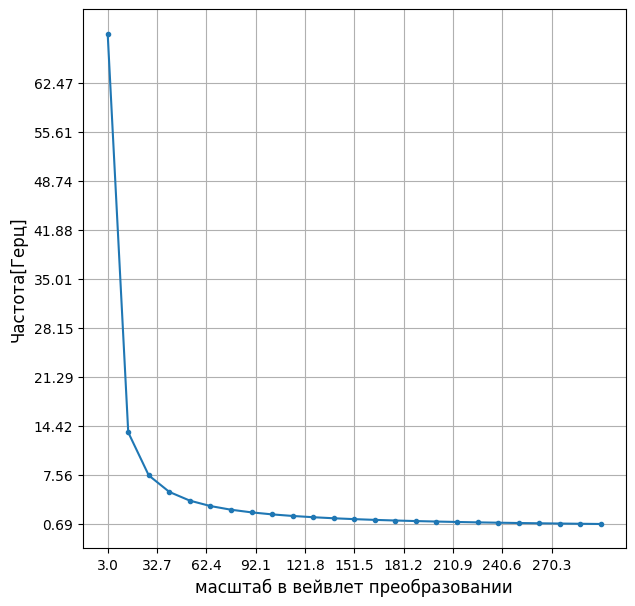

In [51]:
# вейвлет-преобразование построено относительно масштаба материнского вейвлета
# чтобы вернуться в область частот - необходимо перевести масштаб в частоту!
#f = pywt.scale2frequency(wavelet_core, scales)/(T/N)
f = pywt.scale2frequency(wavelet_core, scales)/dt

# изобразим график зависимости частоты и масштаба
plt.figure(figsize=(7, 7))
plt.grid()
plt.yticks(np.arange(min(freqs), max(freqs), (max(freqs) - min(freqs))/10))
plt.xticks(np.arange(min(scales), max(scales), (max(scales) - min(scales))/10))
plt.ylabel('Частота[Герц]', fontsize=12)
plt.xlabel('масштаб в вейвлет преобразовании', fontsize=12)
plt.plot(scales, freqs,'.-')

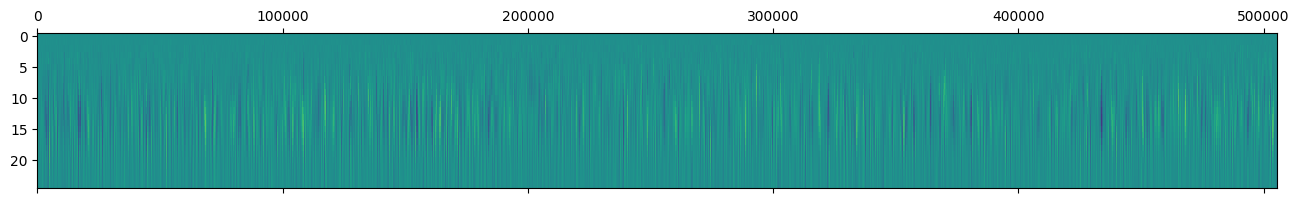

In [52]:
plt.matshow(coef,aspect = 'auto')

Text(0.5, 1.0, 'сигнал в области времени')

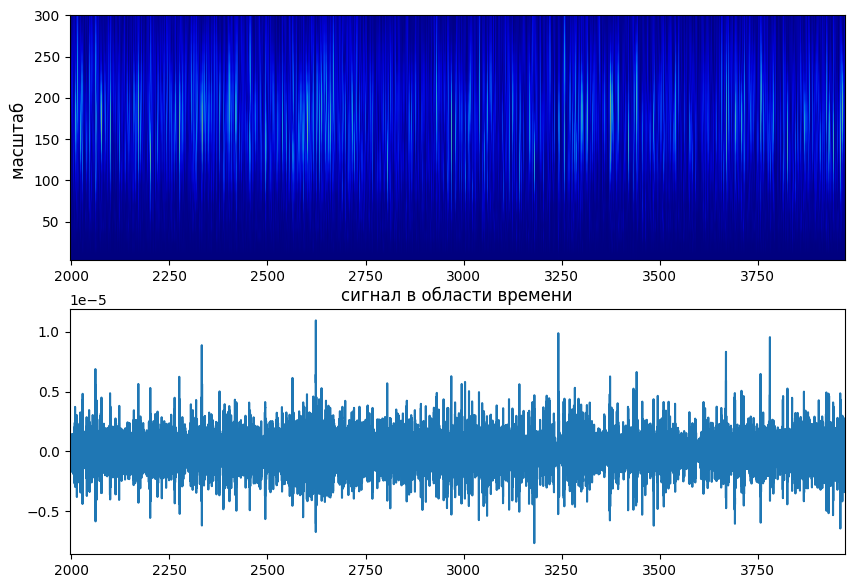

In [53]:
plt.figure(figsize=(10, 7))

ax1 = plt.subplot(211)
#plt.imshow(abs(coef), extent=[t[0], t[-1], scale_max, 0], interpolation='bilinear', cmap='plasma', aspect='auto')
plt.imshow(abs(coef), cmap='jet', aspect='auto', extent=[t[0], t[-1], max(scales), min(scales)], vmax=abs(coef).max(), vmin=abs(coef).min())
plt.gca().invert_yaxis ()
plt.ylabel('масштаб ', fontsize=12)

ax2 = plt.subplot(212, sharex=ax1)
plt.plot(t, y)
ax2.set_title("сигнал в области времени")

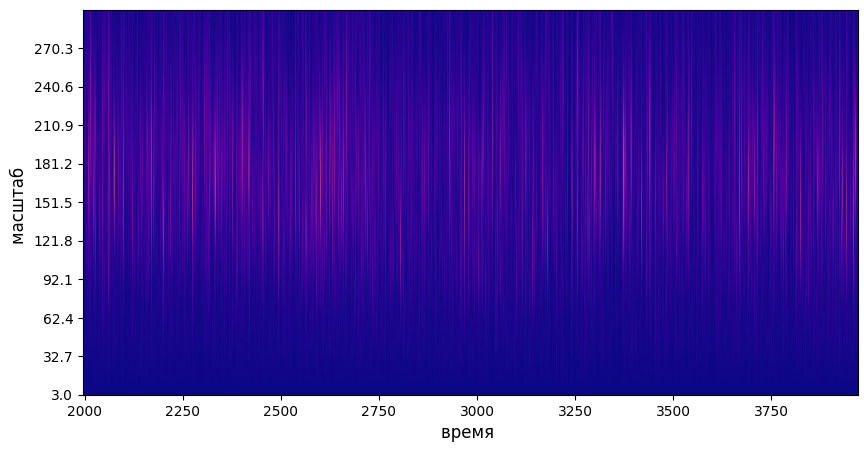

In [54]:
#Plotting scalogram
plt.figure(figsize=(10, 5))
plt.imshow(abs(coef), extent=[t[0], t[-1], max(scales), min(scales)], interpolation='bilinear', cmap='plasma', aspect='auto')
#plt.imshow(abs(coef), interpolation='bilinear', cmap='plasma', aspect='auto')
plt.gca().invert_yaxis ()
plt.yticks(np.arange(min(scales), max(scales), (max(scales) - min(scales))/10))
plt.ylabel('масштаб ', fontsize=12)
plt.xlabel('время ', fontsize=12)
plt.show()

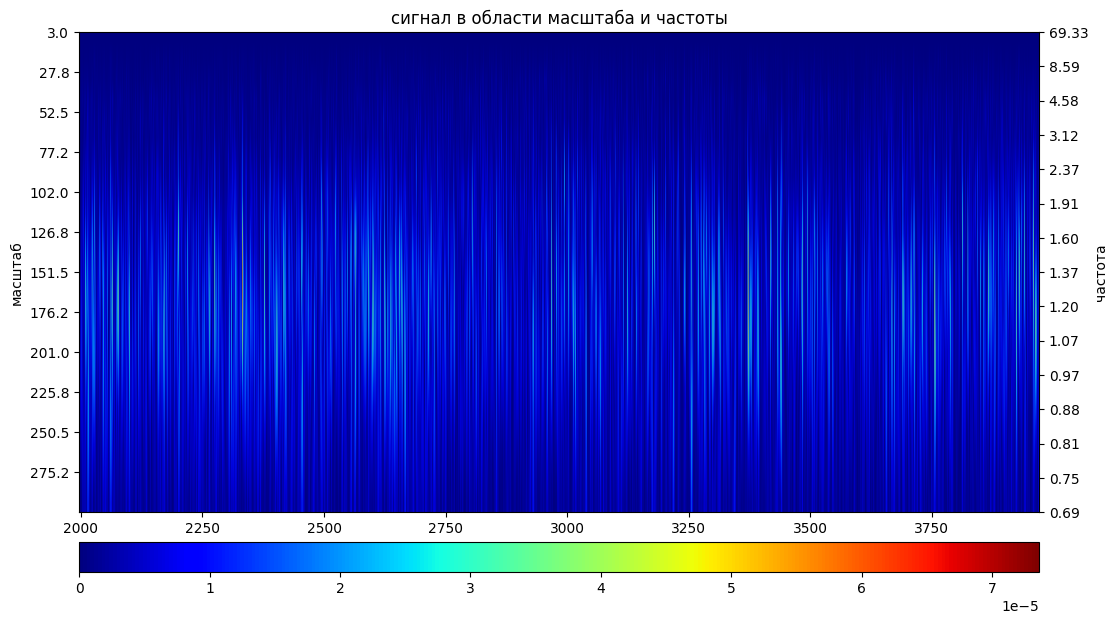

In [55]:
from matplotlib.figure import cbar
from matplotlib.ticker import FuncFormatter
import mpl_toolkits.axes_grid1 as axes_grid1
import matplotlib.ticker as ticker

#Plotting dual axis scalogram
f1 = plt.figure()
f1.set_size_inches(12, 6)


ax1 = axes_grid1.host_axes([0.1, 0.1, 0.8, 0.80])
axc = f1.add_axes([0.1, 0, 0.8, 0.05])
im1 = ax1.imshow(abs(coef), cmap='jet', aspect='auto', interpolation='bilinear',
                 extent=[t[0], t[-1], max(scales), min(scales)],
                 vmax=abs(coef).max(), vmin=-abs(coef).min())

cbar.Colorbar(axc, im1, orientation='horizontal')

#ax1.invert_yaxis()
ax1.set_yticks(np.arange(min(scales), max(scales), (max(scales) - min(scales))/12))


ax2 = ax1.twinx()
# make ticklabels on the top invisible
ax2.axis["top"].toggle(ticklabels=False)

formatter = FuncFormatter(lambda x, pos: '{:0.2f}'.format(pywt.scale2frequency(wavelet_core, x)/dt))
ax2.yaxis.set_major_formatter(formatter)
ax2.set_ylim(ax1.get_ylim())
#ax2.invert_yaxis()

# make number ticks what we want
#ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax2.yaxis.set_major_locator(ticker.LinearLocator(numticks = 15))


ax2.set_ylabel('частота')
ax1.set_ylabel('масштаб')
ax2.set_xlabel('время')

ax1.set_title("сигнал в области масштаба и частоты")

plt.show()